In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from scipy.stats import chi2_contingency

wr.filterwarnings('ignore')

# Upload dataset
df = pd.read_csv("Dataset/in-vehicle-coupon-recommendation.csv")

#DROP DUPLICATE ROWS
df = df.drop_duplicates()
print("Duplicate values: " + str(df.duplicated().sum()))

Duplicate values: 0


In [2]:
#DROP COLUMNS
df = df.drop(columns=['car', 'direction_same', 'toCoupon_GEQ5min'])
print("Shape of the dataset: " + str(df.shape))

Shape of the dataset: (12610, 23)


In [3]:
#FILL MISSING VALUES
missing_columns = df.columns[df.isnull().any()]
for col in missing_columns:
    mod_deger = df[col].mode()[0]
    df[col] = df[col].fillna(mod_deger)
    print(f"Missing values in column '{col}' filled with '{mod_deger}'.")

print("Missing values:\n" + str(df.isnull().sum()))

Missing values in column 'Bar' filled with 'never'.
Missing values in column 'CoffeeHouse' filled with 'less1'.
Missing values in column 'CarryAway' filled with '1~3'.
Missing values in column 'RestaurantLessThan20' filled with '1~3'.
Missing values in column 'Restaurant20To50' filled with 'less1'.
Missing values:
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_opp           0
Y                       0
dtype: int64


Grafik kaydedildi: Results/Analyze/Version2/Univariate/acceptance_by_to_coupon.png


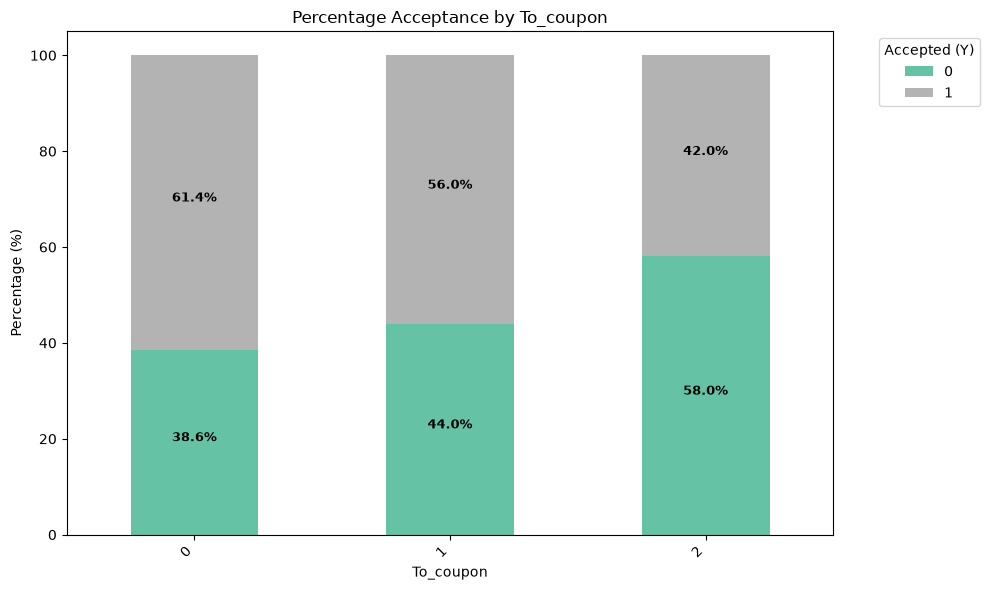

In [4]:
#NEW FEATURES - to_coupon 
conditions = [
    (df["toCoupon_GEQ15min"] == 0) & (df["toCoupon_GEQ25min"] == 0),
    (df["toCoupon_GEQ15min"] == 1) & (df["toCoupon_GEQ25min"] == 0),
    (df["toCoupon_GEQ25min"] == 1),
]
choices = [0, 1, 2]
df["to_coupon"] = np.select(conditions, choices, default=-1)
df = df.drop(columns=['toCoupon_GEQ15min', 'toCoupon_GEQ25min'])

from dataset_analyze import univariate_analysis, faceted_bivariate_analysis, plot_cramers_v_matrix

univariate_analysis('to_coupon', df, "Results/Analyze/Version2/Univariate")

Çoklu grafik kaydedildi: Results/Analyze/Version2/Faceted_Bivariate/count_coupon_frequency_by_coupon_split_by_Y.png


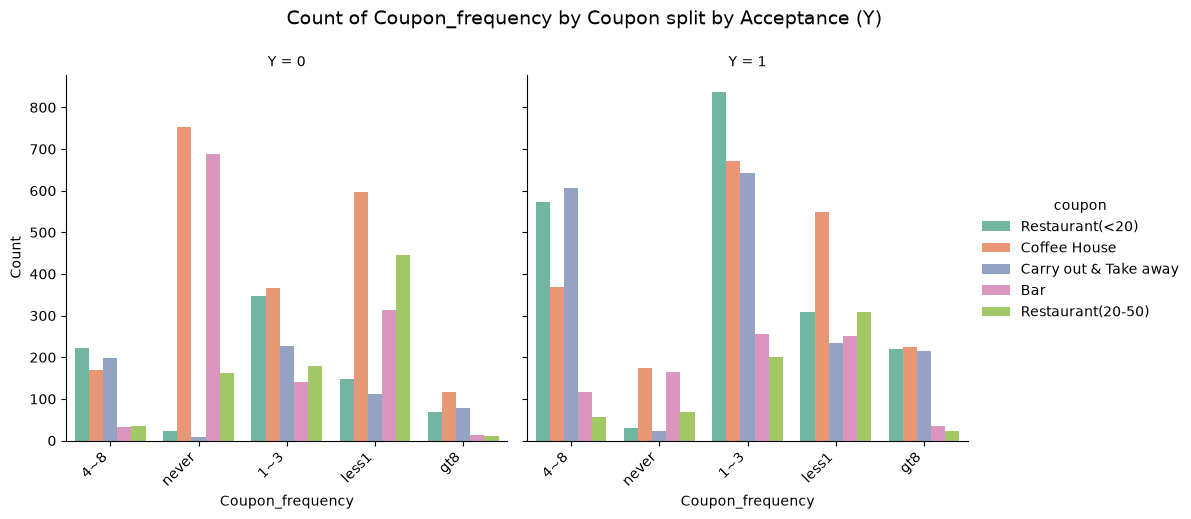

In [5]:
#NEW FEATURES - coupon_frequency
conditions = [
    (df["coupon"] == "Restaurant(<20)"),
    (df["coupon"] == "Coffee House"),
    (df["coupon"] == "Carry out & Take away"),
    (df["coupon"] == "Bar"),
    (df["coupon"] == "Restaurant(20-50)")
]
choices = [df["RestaurantLessThan20"], df["CoffeeHouse"], df["CarryAway"], df["Bar"], df["Restaurant20To50"]]
df["coupon_frequency"] = np.select(conditions, choices, default=np.nan)
df = df.drop(columns=['RestaurantLessThan20', 'CoffeeHouse', 'CarryAway', 'Bar', 'Restaurant20To50'])

faceted_bivariate_analysis('coupon_frequency', 'coupon', df, "Results/Analyze/Version2/Faceted_Bivariate")

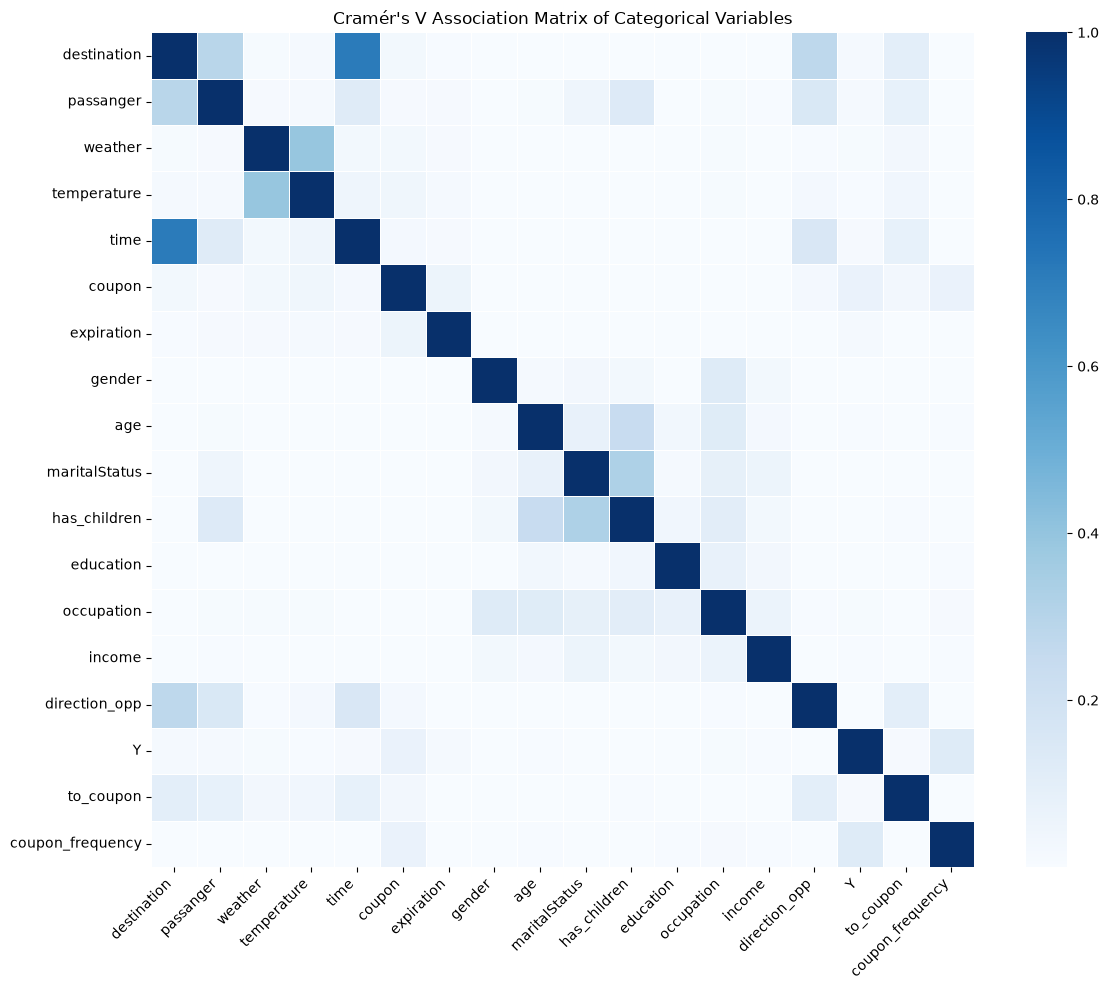

In [6]:
plot_cramers_v_matrix(df)
df.to_csv("Dataset/preprocessed_dataset.csv", index=False)